(1960, 12)
['Order_ID', 'Order_Date', 'Customer_Name', 'City', 'Category', 'Product', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Payment_Method', 'Delivery_Status', 'Total Amount']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1960 entries, 0 to 1959
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Order_ID         1960 non-null   object
 1   Order_Date       1960 non-null   object
 2   Customer_Name    1960 non-null   object
 3   City             1960 non-null   object
 4   Category         1960 non-null   object
 5   Product          1960 non-null   object
 6   Quantity         1960 non-null   int64 
 7   Unit_Price       1960 non-null   int64 
 8   Discount_Pct     1960 non-null   int64 
 9   Payment_Method   1960 non-null   object
 10  Delivery_Status  1960 non-null   object
 11  Total Amount     1960 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 183.9+ KB
4406570.550000001
2024-01-01 0

/tmp/ipykernel_2044/1084773442.py:9: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"])


<Axes: title={'center': 'Monthly Sales'}, xlabel='Order_Date'>

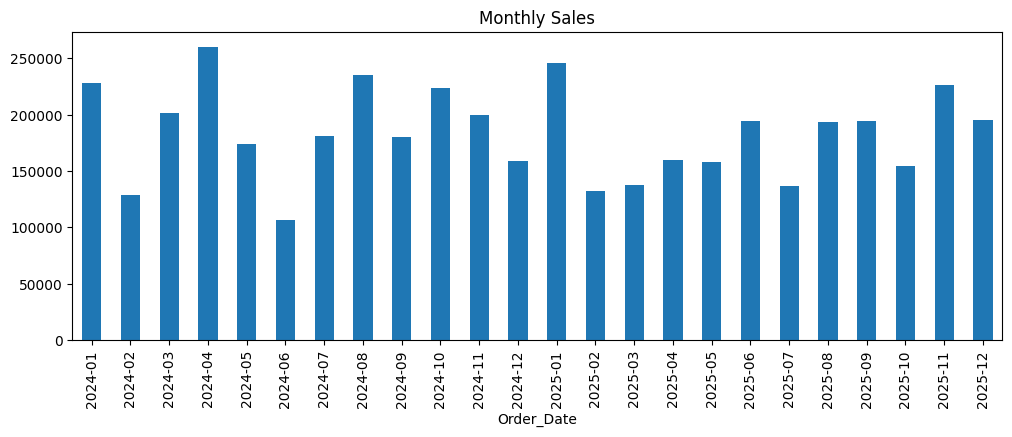

In [19]:
import pandas as pd

df = pd.read_csv("sales_clean.csv")
df.head()
print(df.shape)
print(df.columns.tolist())
df.info()
df.columns = df.columns.str.replace(" ", "_")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df.dtypes
valid = df[df["Delivery_Status"].isin(["Delivered", "In Transit"])]

valid.groupby("Category")["Total_Amount"].sum().round(0).sort_values(ascending=False)
df["Total_Amount"] = df["Quantity"] * df["Unit_Price"] * (1 - df["Discount_Pct"] / 100)

valid = df[df["Delivery_Status"].isin(["Delivered", "In Transit"])]
print(valid["Total_Amount"].sum())
valid.groupby("Category")["Total_Amount"].sum().round(0).sort_values(ascending=False)
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y %H:%M")
print(df["Order_Date"].min(), df["Order_Date"].max())
monthly = valid.groupby(valid["Order_Date"].dt.to_period("M"))["Total_Amount"].sum()
monthly.plot(kind="bar", figsize=(12, 4), title="Monthly Sales")
